# Container No-Go Zones

> **Mode:** Simulation (`STARChatterboxBackend`) - no hardware required.
>
> **Topic:** Defining obstructed regions and automatic channel avoidance using `Container` no-go zones.
>
> **Extra dependencies** (not included in pylabrobot):
>   - `matplotlib` - used for cross-section visualizations in this tutorial only

---

## What are no-go zones?

Some containers have internal obstructions - divider walls, support beams, baffles - where pipette tips physically cannot go. When multiple channels target the same container (e.g. aspirating from a trough with 4 channels), `LiquidHandler` needs to know where these obstructions are to position tips safely.

A **no-go zone** is a cuboid region inside a container, defined as a `Tuple[Coordinate, Coordinate]` - the front-left-bottom and back-right-top corners, relative to the container's origin.

## How it works

When `LiquidHandler.aspirate` or `.dispense` targets a single container with multiple channels:

1. The container's Y axis is split into **compartments** (free space between no-go zones)
2. Each compartment is shrunk by `edge_clearance` (default 2mm) from each boundary
3. Channels are distributed across compartments **center-out, then back-first**
4. Each channel group is centered within its compartment

```{note}
Single-channel operations are unaffected - the tip goes to the container center as usual.
```

In [ ]:
# Imports and visualization helper (collapse this cell in Jupyter via View → Collapse)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from pylabrobot.resources.container import Container
from pylabrobot.resources.coordinate import Coordinate
from pylabrobot.liquid_handling.utils import (
    _get_compartments,
    compute_channel_offsets,
    center_channels_in_compartments,
    MIN_SPACING_EDGE,
)

In [2]:
MIN_CHANNEL_SPACING = 9.0  # mm, default minimum spacing between channel centers

def plot_container_cross_section(container, num_channels_list):
    """Plot a Y-axis cross section of a container showing no-go zones, compartments, and channels.

    Args:
        container: Container with no_go_zones defined.
        num_channels_list: List of channel counts to show (one subplot per count).
    """
    n_plots = len(num_channels_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(2 * n_plots, 5), squeeze=False)
    axes = axes[0]

    size_y = container.get_absolute_size_y()
    size_x = container.get_absolute_size_x()
    center_y = size_y / 2
    compartments = _get_compartments(container)
    channel_radius = MIN_CHANNEL_SPACING / 2
    label_bbox = dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0.3)

    for ax, n_ch in zip(axes, num_channels_list):
        # Container outline (Y on vertical axis, X on horizontal)
        ax.add_patch(plt.Rectangle((0, 0), size_x, size_y, fill=False,
                                    edgecolor="black", linewidth=2))

        # No-go zones (red)
        for flb, brt in container.no_go_zones:
            ax.add_patch(plt.Rectangle((0, flb.y), size_x, brt.y - flb.y,
                                        facecolor="red", alpha=0.3, edgecolor="red", linewidth=1))

        # Free compartments (green)
        for comp_lo, comp_hi in compartments:
            ax.add_patch(plt.Rectangle((0, comp_lo), size_x, comp_hi - comp_lo,
                                        facecolor="green", alpha=0.1, edgecolor="green",
                                        linewidth=1, linestyle="--"))

        # Channel positions
        offsets = compute_channel_offsets(container, n_ch)
        if offsets is not None:
            for i, o in enumerate(offsets):
                tip_y = center_y + o.y
                # Channel diameter circle (9mm, transparent)
                ax.add_patch(plt.Circle(
                    (size_x / 2, tip_y), channel_radius,
                    facecolor="none", edgecolor="navy", linewidth=1, linestyle=":"))
                # Center marker
                ax.plot(size_x / 2, tip_y, "o", color="navy", markersize=4, zorder=5)
                # Label with white background
                ax.text(size_x + 1.5, tip_y, f"ch{i}", ha="left", va="center",
                        fontsize=6, color="navy", bbox=label_bbox, zorder=6)
        else:
            ax.text(size_x / 2, size_y / 2, "Cannot fit!", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")

        ax.set_xlim(-2, size_x + 8)
        ax.set_ylim(-2, size_y + 2)
        ax.set_xlabel("X (mm)")
        if ax == axes[0]:
            ax.set_ylabel("Y (mm)")
        else:
            ax.set_yticklabels([])
            ax.set_ylabel("")
        ax.set_title(f"{n_ch} channel{'s' if n_ch != 1 else ''}")
        ax.set_aspect("equal")

    # Legend
    legend_handles = [
        mpatches.Patch(facecolor="red", alpha=0.3, edgecolor="red", label="No-go zone"),
        mpatches.Patch(facecolor="green", alpha=0.1, edgecolor="green", label="Free compartment"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markeredgecolor="navy",
               markersize=10, linestyle="None", label="Channel diameter"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=8)

    name = container.name
    model = container.model or ""
    fig.suptitle(f"{name} ({model})\nsize_y={size_y}mm, {len(container.no_go_zones)} no-go zone(s)",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=[0, 0.06, 1, 0.92])
    fig.subplots_adjust(wspace=-0.1)
    plt.show()

## Real-world examples: Hamilton troughs

The Hamilton trough family has internal support structures that create no-go zones. These were measured from physical troughs using calipers (top of beams) and visual inspection through the transparent walls (base of tapered beams).

### 60 mL trough - 1 center divider

The `hamilton_1_trough_60mL_Vb` has a single center support wall (~1.2mm wide), creating 2 compartments.

Container: trough_60mL, size_y=90.0mm
No-go zones: [(Coordinate(x=0, y=44.4, z=5.0), Coordinate(x=19.0, y=45.6, z=60.25))]
Compartments: [(2.0, 42.4), (47.6, 88.0)]


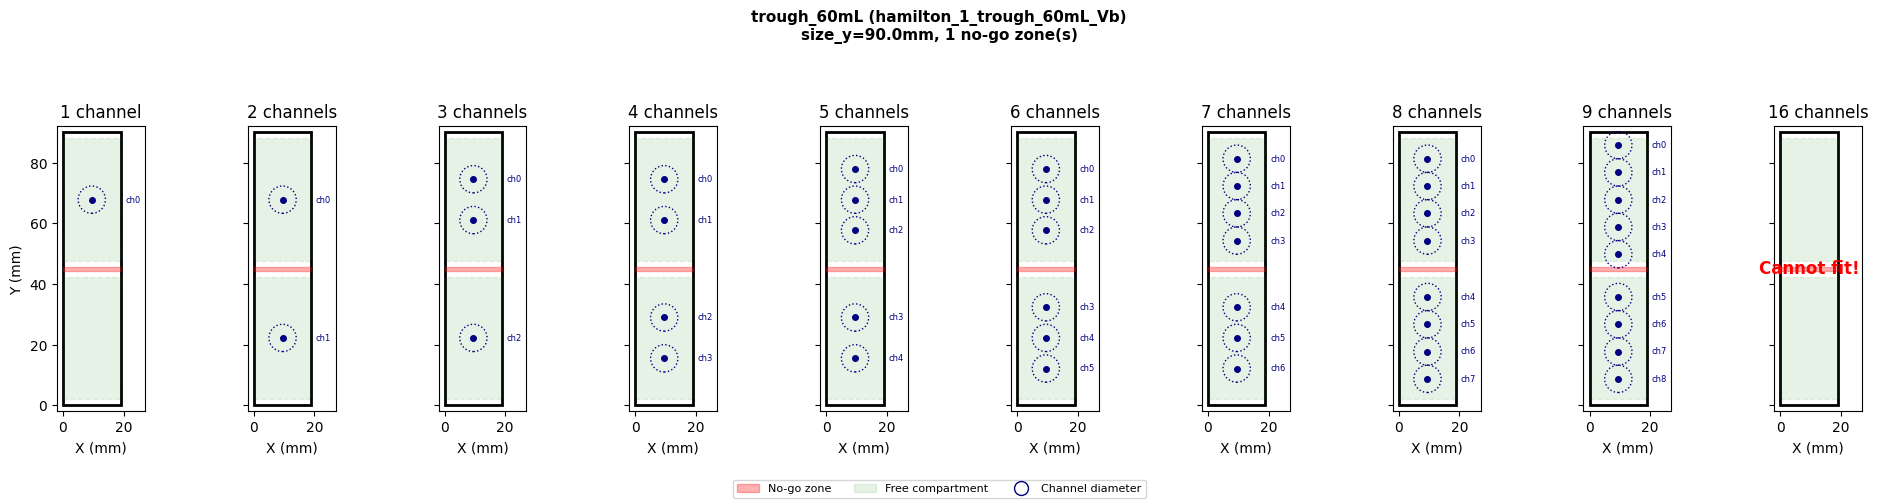

In [3]:
from pylabrobot.resources.hamilton.troughs import hamilton_1_trough_60mL_Vb

trough_60 = hamilton_1_trough_60mL_Vb(name="trough_60mL")

print(f"Container: {trough_60.name}, size_y={trough_60.get_absolute_size_y()}mm")
print(f"No-go zones: {trough_60.no_go_zones}")
print(f"Compartments: {_get_compartments(trough_60)}")

plot_container_cross_section(trough_60, [1, 2, 3, 4, 5, 6, 7, 8, 9, 16])

### 120 mL trough - 3 tapered support beams

The `hamilton_1_trough_120mL_Vb` has 3 internal support beams (~2.5mm wide at the base, ~0.8mm at the top), creating 4 compartments. The no-go zones use the base width since that is the worst case for pipette tip clearance.

Dimensional breakdown (from outer y=0):

| Element | Y range (mm) | Size (mm) | Modelled as |
|---|---|---|---|
| Back wall | 141.1 - 142.5 | 1.4 | Not modelled (included in `size_y`) |
| Compartment 3 | 109.8 - 141.1 | 31.3 | Free space |
| Beam 3 | 107.3 - 109.8 | 2.5 | `no_go_zones[2]` |
| Compartment 2 | 76.0 - 107.3 | 31.3 | Free space |
| Beam 2 | 73.5 - 76.0 | 2.5 | `no_go_zones[1]` |
| Compartment 1 | 42.2 - 73.5 | 31.3 | Free space |
| Beam 1 | 39.7 - 42.2 | 2.5 | `no_go_zones[0]` |
| Compartment 0 | 1.2 - 39.7 | 38.5 | Free space |
| Front wall | 0 - 1.2 | 1.2 | Not modelled (included in `size_y`) |

```{note}
size_y=142.5` is the **outer** dimension of the trough.
The front and back walls are not modelled as no-go zones - they are accounted for by the `edge_clearance` parameter during channel positioning.

The internal beams *are* modelled as no-go zones because they obstruct pipette access within the container's interior.
```

Container: trough_120mL, size_y=142.5mm
No-go zones: [(Coordinate(x=0, y=39.7, z=12.0), Coordinate(x=19.0, y=42.2, z=70.0)), (Coordinate(x=0, y=73.5, z=12.0), Coordinate(x=19.0, y=76.0, z=70.0)), (Coordinate(x=0, y=107.3, z=12.0), Coordinate(x=19.0, y=109.8, z=70.0))]
Compartments: [(2.0, 37.7), (44.2, 71.5), (78.0, 105.3), (111.8, 140.5)]


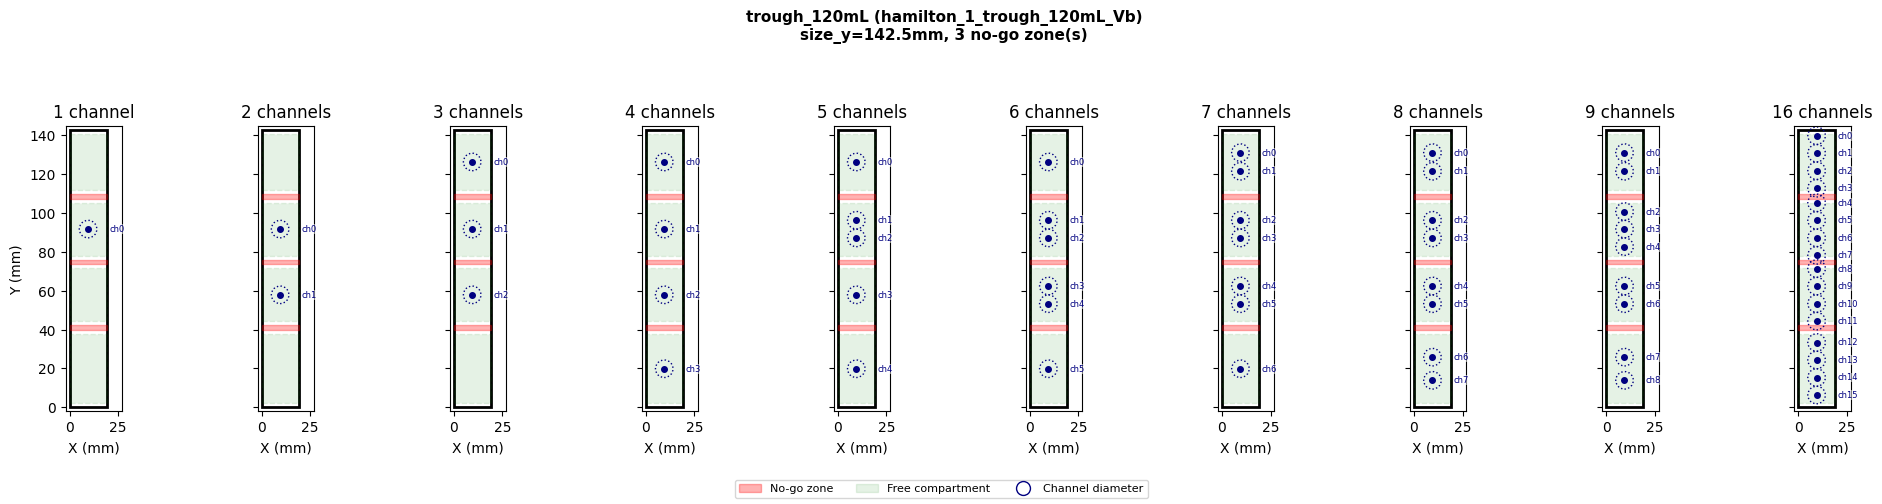

In [4]:
from pylabrobot.resources.hamilton.troughs import hamilton_1_trough_120mL_Vb

trough_120 = hamilton_1_trough_120mL_Vb(name="trough_120mL")

print(f"Container: {trough_120.name}, size_y={trough_120.get_absolute_size_y()}mm")
print(f"No-go zones: {trough_120.no_go_zones}")
print(f"Compartments: {_get_compartments(trough_120)}")

plot_container_cross_section(trough_120, [1, 2, 3, 4, 5, 6, 7, 8, 9, 16])

## Defining no-go zones on a new container

Any `Container` (or subclass: `Trough`, `Well`, `Tube`, etc.) accepts a `no_go_zones` parameter. Each zone is a pair of `Coordinate`s - the front-left-bottom and back-right-top corners of the obstructed cuboid, relative to the container's outer origin.

Container: custom_trough, size_y=100.0mm
Compartments: [(2.0, 28.0), (34.0, 63.0), (69.0, 98.0)]


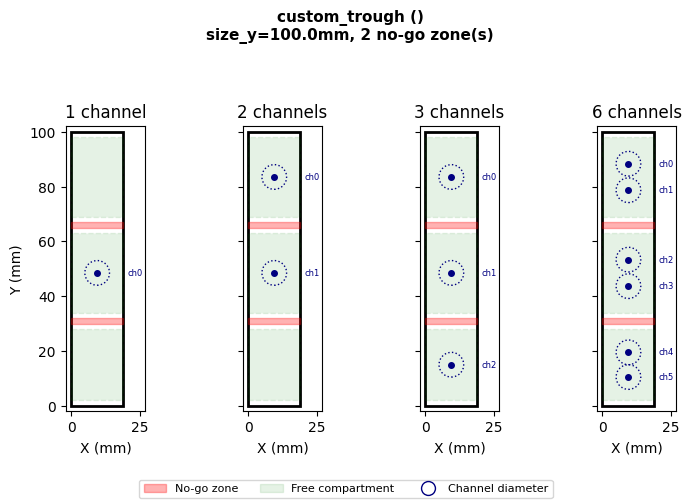

In [5]:
from pylabrobot.resources.trough import Trough, TroughBottomType

# Define a custom trough with two dividers
custom_trough = Trough(
    name="custom_trough",
    size_x=19.0,
    size_y=100.0,
    size_z=50.0,
    max_volume=80_000,
    bottom_type=TroughBottomType.V,
    no_go_zones=[
        (Coordinate(0, 30.0, 0), Coordinate(19.0, 32.0, 50.0)),  # divider 1
        (Coordinate(0, 65.0, 0), Coordinate(19.0, 67.0, 50.0)),  # divider 2
    ],
)

print(f"Container: {custom_trough.name}, size_y={custom_trough.get_absolute_size_y()}mm")
print(f"Compartments: {_get_compartments(custom_trough)}")

plot_container_cross_section(custom_trough, [1, 2, 3, 6])

## Edge clearance and tip size

`edge_clearance` (default: `MIN_SPACING_EDGE = 2mm`) controls how close the automatic positioning places tip **centers** to compartment boundaries. It is a positioning safety margin, not a physical gate.

It does **not** prevent a pipette from entering a container. Whether a tip physically fits is determined by tip diameter vs. container opening - e.g. a 1000 µL tip won't fit into a 1536-wellplate well. This is the **user's responsibility** to verify when choosing tips and containers.

Container size_y: 20.0mm
No-go zone: Y=8-12mm → two 8mm raw compartments
After 2mm edge clearance: compartments = [(2.0, 6.0), (14.0, 18.0)]
1 channel: [Coordinate(x=0, y=6.0, z=0)]
2 channels (1 per compartment): [Coordinate(x=0, y=6.0, z=0), Coordinate(x=0, y=-6.0, z=0)]
3 channels (needs 2 in one 4mm compartment → fails): None


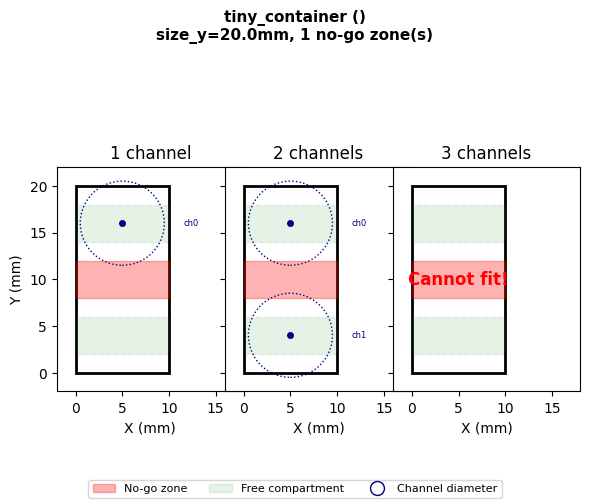

In [6]:
# A narrow container where compartments are smaller than the default 9mm channel spacing.
# 1 channel per compartment still works - the channel is simply centered.
# 2 channels in one compartment would fail (needs 9mm, only 4mm available).
tiny = Container(
    name="tiny_container", size_x=10, size_y=20, size_z=10,
    no_go_zones=[(Coordinate(0, 8, 0), Coordinate(10, 12, 10))],
)
print(f"Container size_y: {tiny.get_absolute_size_y()}mm")
print(f"No-go zone: Y={8}-{12}mm → two 8mm raw compartments")
print(f"After 2mm edge clearance: compartments = {_get_compartments(tiny)}")
print(f"1 channel: {center_channels_in_compartments(tiny, 1)}")
print(f"2 channels (1 per compartment): {center_channels_in_compartments(tiny, 2)}")
print(f"3 channels (needs 2 in one 4mm compartment → fails): {center_channels_in_compartments(tiny, 3)}")
plot_container_cross_section(tiny, [1, 2, 3])

## Spread modes with no-go zones

The `spread` parameter on `aspirate` and `dispense` controls how channels are positioned within each compartment:

- `spread="wide"` (default) - channels are spread as far apart as possible within each compartment
- `spread="tight"` - channels are packed at minimum spacing (9mm), centered in each compartment
- `spread="custom"` - no-go zones are ignored entirely; the user controls all positioning via offsets

In [ ]:
# Compare wide vs tight spread on the 200mL trough (2 large compartments, 6 channels)
from pylabrobot.resources.hamilton.troughs import hamilton_1_trough_200mL_Vb

trough_200 = hamilton_1_trough_200mL_Vb(name="trough_200mL")
print(f"Compartments: {_get_compartments(trough_200)}")

for mode in ["wide", "tight"]:
    offsets = compute_channel_offsets(trough_200, 6, spread=mode)
    positions = [f"{o.y:+.1f}" for o in offsets]
    print(f"spread={mode!r:8s} -> offsets (from center): {positions}")

In [ ]:
# Visual comparison: 6 channels on the 200mL trough with wide vs tight
# The 200mL trough has 2 large compartments (~55mm each) where the difference is clearly visible
fig, axes = plt.subplots(1, 2, figsize=(6, 5), squeeze=False)
axes = axes[0]

size_y = trough_200.get_absolute_size_y()
size_x = trough_200.get_absolute_size_x()
center_y = size_y / 2
compartments = _get_compartments(trough_200)
channel_radius = 9.0 / 2
label_bbox = dict(facecolor="white", alpha=0.5, edgecolor="none", pad=0.3)

for ax, mode in zip(axes, ["wide", "tight"]):
    ax.add_patch(plt.Rectangle((0, 0), size_x, size_y, fill=False, edgecolor="black", linewidth=2))
    for flb, brt in trough_200.no_go_zones:
        ax.add_patch(plt.Rectangle((0, flb.y), size_x, brt.y - flb.y,
                                    facecolor="red", alpha=0.3, edgecolor="red", linewidth=1))
    for comp_lo, comp_hi in compartments:
        ax.add_patch(plt.Rectangle((0, comp_lo), size_x, comp_hi - comp_lo,
                                    facecolor="green", alpha=0.1, edgecolor="green",
                                    linewidth=1, linestyle="--"))

    offsets = compute_channel_offsets(trough_200, 6, spread=mode)
    for i, o in enumerate(offsets):
        tip_y = center_y + o.y
        ax.add_patch(plt.Circle((size_x / 2, tip_y), channel_radius,
                                 facecolor="none", edgecolor="navy", linewidth=1, linestyle=":"))
        ax.plot(size_x / 2, tip_y, "o", color="navy", markersize=4, zorder=5)
        ax.text(size_x + 1.5, tip_y, f"ch{i}", ha="left", va="center",
                fontsize=6, color="navy", bbox=label_bbox, zorder=6)

    ax.set_xlim(-2, size_x + 8)
    ax.set_ylim(-2, size_y + 2)
    ax.set_xlabel("X (mm)")
    ax.set_title(f'spread="{mode}"')
    ax.set_aspect("equal")

axes[0].set_ylabel("Y (mm)")
axes[1].set_yticklabels([])
fig.suptitle("6 channels on 200mL trough: wide vs tight", fontsize=11, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.subplots_adjust(wspace=-0.1)
plt.show()

## Try it yourself

Edit the parameters below to experiment with any container geometry:

Compartments: [(2.0, 28.0), (34.0, 63.0), (69.0, 98.0)]
  1 ch: ['y=-1.5']
  2 ch: ['y=+33.5', 'y=-1.5']
  3 ch: ['y=+33.5', 'y=-1.5', 'y=-35.0']
  6 ch: ['y=+38.3', 'y=+28.7', 'y=+3.3', 'y=-6.3', 'y=-30.5', 'y=-39.5']


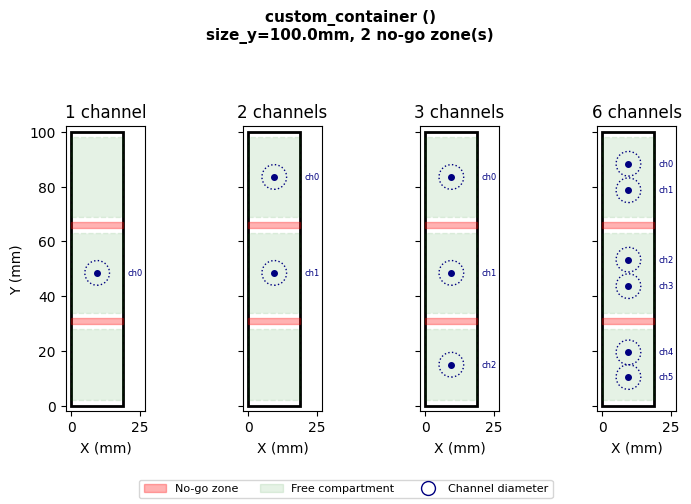

In [9]:
# --- Edit these ---
CONTAINER_SIZE_X = 19.0   # mm
CONTAINER_SIZE_Y = 100.0  # mm
CONTAINER_SIZE_Z = 50.0   # mm

# List of (y_start, y_end) pairs for no-go zones
NO_GO_Y_RANGES = [
    (30, 32),   # divider 1
    (65, 67),   # divider 2
]

NUM_CHANNELS = [1, 2, 3, 6]  # channel counts to plot
# ------------------

no_go_zones = [
    (Coordinate(0, y_lo, 0), Coordinate(CONTAINER_SIZE_X, y_hi, CONTAINER_SIZE_Z))
    for y_lo, y_hi in NO_GO_Y_RANGES
]

custom = Container(
    name="custom_container",
    size_x=CONTAINER_SIZE_X,
    size_y=CONTAINER_SIZE_Y,
    size_z=CONTAINER_SIZE_Z,
    no_go_zones=no_go_zones,
)

print(f"Compartments: {_get_compartments(custom)}")
for n in NUM_CHANNELS:
    result = center_channels_in_compartments(custom, n)
    status = [f"y={o.y:+.1f}" for o in result] if result else "Cannot fit"
    print(f"  {n} ch: {status}")

plot_container_cross_section(custom, NUM_CHANNELS)

## End-to-end simulation

Below we set up a full `LiquidHandler` with `STARChatterboxBackend` (simulation - no hardware needed) to verify that `aspirate` correctly distributes channels around no-go zones.

The Hamilton-specific trough definitions (`hamilton_1_trough_60mL_Vb`, `hamilton_1_trough_120mL_Vb`) already have `no_go_zones` pre-configured - you don't need to define them manually when using these resources.

In [10]:
from pylabrobot.liquid_handling import LiquidHandler
from pylabrobot.liquid_handling.backends.hamilton.STAR_chatterbox import STARChatterboxBackend
from pylabrobot.resources.hamilton import STARLetDeck
from pylabrobot.resources.hamilton.tip_racks import hamilton_96_tiprack_1000uL_filter
from pylabrobot.resources.hamilton.trough_carriers import Trough_CAR_5R60_A00
from pylabrobot.resources.hamilton.troughs import hamilton_1_trough_60mL_Vb
from pylabrobot.resources import TIP_CAR_480_A00, set_tip_tracking, set_volume_tracking

set_tip_tracking(True)
set_volume_tracking(True)

backend = STARChatterboxBackend(num_channels=8)
deck = STARLetDeck()
lh = LiquidHandler(backend=backend, deck=deck)
await lh.setup()

tip_car = TIP_CAR_480_A00(name="tip_carrier")
tip_car[0] = hamilton_96_tiprack_1000uL_filter(name="tips_1000")
deck.assign_child_resource(tip_car, rails=1)

trough_car = Trough_CAR_5R60_A00(name="trough_carrier")
trough_car[0] = hamilton_1_trough_60mL_Vb(name="trough_60")
deck.assign_child_resource(trough_car, rails=10)

trough = deck.get_resource("trough_60")
print(f"Trough: {trough.name}")
print(f"Pre-configured no-go zones: {trough.no_go_zones}")
print(f"Compartments: {_get_compartments(trough)}")

Trough: trough_60
Pre-configured no-go zones: [(Coordinate(x=0, y=44.4, z=5.0), Coordinate(x=19.0, y=45.6, z=60.25))]
Compartments: [(2.0, 42.4), (47.6, 88.0)]


### Aspirate with 2 and 4 channels

Pick up tips, fill the trough, then aspirate. The chatterbox backend prints raw firmware commands - the `yp` values show absolute Y positions in 0.1mm units. Verify that channels land in separate compartments and avoid the divider at Y=44-46mm.

C0TTid0001tt01tf1tl0871tv10650tg3tu0
C0TPid0002xp01179 01179 01179 01179 00000&yp1458 1368 1278 1188 0000&tm1 1 1 1 0&tt01tp2266tz2166th2450td0
2 channels → offsets: ['+22.8mm', '-22.8mm']
4 channels → offsets: ['+29.5mm', '+16.1mm', '-16.1mm', '-29.5mm']


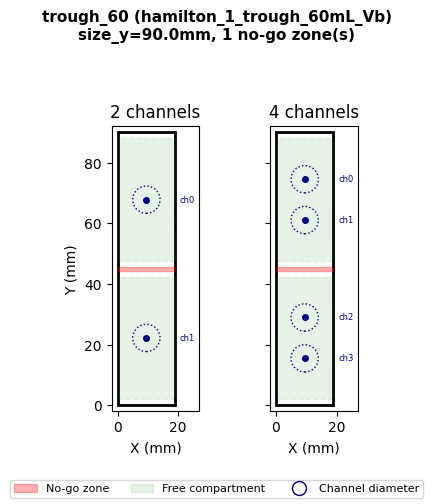

In [11]:
tip_rack = deck.get_resource("tips_1000")
await lh.pick_up_tips(tip_rack["A1:D1"])
trough.tracker.set_volume(50_000)

# Show expected offsets before aspirating
for n in [2, 4]:
    offsets = center_channels_in_compartments(trough, n)
    print(f"{n} channels → offsets: {[f'{o.y:+.1f}mm' for o in offsets]}")

plot_container_cross_section(trough, [2, 4])

In [12]:
await lh.stop()
print("Simulation stopped.")

Simulation stopped.
